# Set up workspace

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import sys

In [3]:
sys.path.append('/glade/u/home/czarakas/coupled_PPE/code/utils')

import quick_map
from load_gridcell_areas import *
from plotting_settings import *

# Load data

In [4]:
dir_input='/glade/work/czarakas/coupled_PPE/data/data_for_figures/EOFs/'
dir_input_means='/glade/work/czarakas/coupled_PPE/data/data_for_figures/annual_means/'

In [5]:
var='TSKIN'
eofs=xr.open_dataset(dir_input+'EOFanalysis_TSKIN_coupled_EOFs.nc')
pcs=xr.open_dataset(dir_input+'EOFanalysis_TSKIN_coupled_PCs.nc')
var_explained=xr.open_dataset(dir_input+'EOFanalysis_TSKIN_coupled_varianceFraction.nc')

pvals=xr.open_dataset(dir_input_means+'pval_TSKIN_Annual_mean_coupled.nc')#['pval']
ds_array=xr.open_dataset(dir_input_means+'delta_TSKIN_Annual_mean_coupled.nc')
ds_ref=xr.open_dataset(dir_input_means+'ref_TSKIN_Annual_mean_coupled.nc')#['calculated_PREC_FROM_ATM']


In [6]:
var='PRECT'
eofs=xr.open_dataset(dir_input+'EOFanalysis_calculated_PREC_FROM_ATM_coupled_EOFs.nc')
pcs=xr.open_dataset(dir_input+'EOFanalysis_calculated_PREC_FROM_ATM_coupled_PCs.nc')
var_explained=xr.open_dataset(dir_input+'EOFanalysis_calculated_PREC_FROM_ATM_coupled_varianceFraction.nc')

pvals=xr.open_dataset(dir_input_means+'pval_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')#['pval']
ds_array=xr.open_dataset(dir_input_means+'delta_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')
ds_ref=xr.open_dataset(dir_input_means+'ref_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')#['calculated_PREC_FROM_ATM']

# Make summary figure

In [7]:
mode_multiplier=2*pcs.pcs.std(dim='time')
#mode_multiplier=-2*pcs.pcs.std(dim='time')

/glade/u/home/czarakas/coupled_PPE/code/utils/quick_map.py:87: MatplotlibDeprecationWarning: 
The set_clim function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use ScalarMappable.set_clim instead.
  cbar.set_clim(clim)
/glade/u/home/czarakas/coupled_PPE/code/utils/quick_map.py:87: MatplotlibDeprecationWarning: 
The set_clim function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use ScalarMappable.set_clim instead.
  cbar.set_clim(clim)
/glade/u/home/czarakas/coupled_PPE/code/utils/quick_map.py:87: MatplotlibDeprecationWarning: 
The set_clim function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use ScalarMappable.set_clim instead.
  cbar.set_clim(clim)


<Figure size 1728x1080 with 0 Axes>

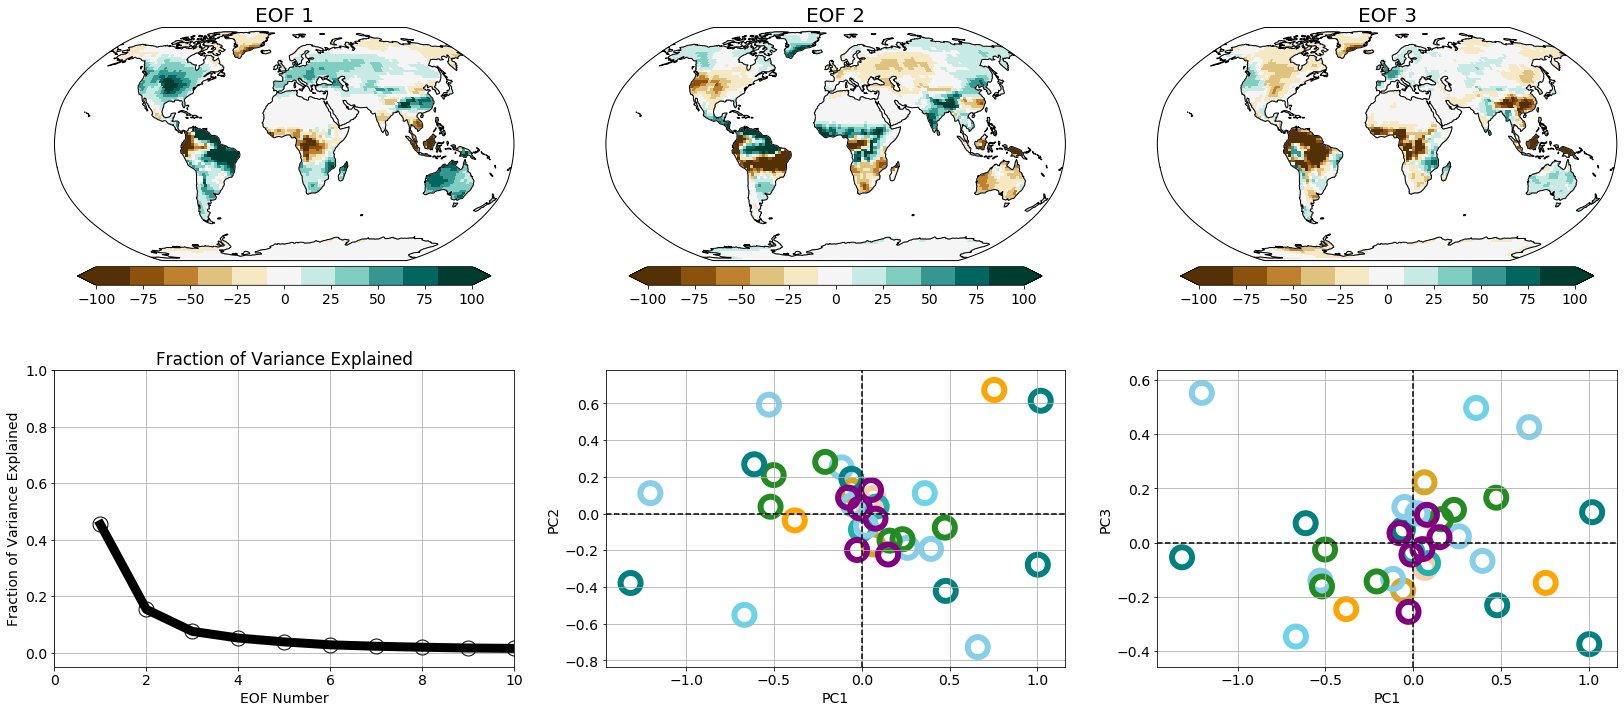

In [9]:
plt.rcParams.update({'font.size': 14})
fig = plt.figure(figsize=(24,15))

lats = eofs['lat'].values
lons = eofs['lon'].values
fig = plt.figure(figsize=(28, 12))
for i in range(0,3):
    if var=='PRECT':
        quick_map.quick_map_subplot(((eofs.eofs[:,:,i])*mode_multiplier[0]/landweights).values,lats,lons, nrow=2, ncol=3, ind=i,
                                clim=[-100,100], cmap=plt.get_cmap('BrBG',11),
                                title='EOF '+str(i+1))
    elif var=='TSKIN':
        quick_map.quick_map_subplot(((eofs.eofs[:,:,i])*mode_multiplier[0]/landweights).values,lats,lons, nrow=2, ncol=3, ind=i,
                                cmap=plt.get_cmap('bwr',11),clim=[-2.25,2.25],
                                title='EOF '+str(i+1))
    
plt.subplot(2,3,4)
plt.plot(var_explained.mode.values+1,var_explained.variance_fractions.values,
         'o-k', fillstyle='none',markersize=15,linewidth=9)#, label=ensemble)
plt.xlim([0,10])
plt.ylim([-0.05,1])
plt.title('Fraction of Variance Explained')
plt.xlabel('EOF Number')
plt.ylabel('Fraction of Variance Explained')
plt.grid()

plt.subplot(2,3,5)
plt.scatter(pcs.pcs[:,0]/mode_multiplier[0], pcs.pcs[:,1]/mode_multiplier[0], s=400, 
            edgecolors=colors,facecolors='none',linewidth=6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.axvline(x=0,linestyle='--',color='k')
plt.axhline(y=0,linestyle='--',color='k')
plt.grid()

plt.subplot(2,3,6)
plt.scatter(pcs.pcs[:,0]/mode_multiplier[0], pcs.pcs[:,2]/mode_multiplier[0], s=400, 
            edgecolors=colors,facecolors='none',linewidth=6)
plt.xlabel('PC1')
plt.ylabel('PC3')
plt.axvline(x=0,linestyle='--',color='k')
plt.axhline(y=0,linestyle='--',color='k')
plt.grid()
plt.savefig('../Figures/Figure_S_'+var+'_EOF_summary.pdf')
#plt.savefig('Figures/Figure_S_Temperature_EOF_summary.pdf')